In [86]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe

RANDOM_STATE = 67

<h2> Load in the data </h2>

In [87]:
df = pd.read_csv("vb_matches.csv")
df

,circuit,tournament,country,year,date,gender,match_num,w_player1,w_p1_birthdate,w_p1_age,...,l_p1_tot_blocks,l_p1_tot_digs,l_p2_tot_attacks,l_p2_tot_kills,l_p2_tot_errors,l_p2_tot_hitpct,l_p2_tot_aces,l_p2_tot_serve_errors,l_p2_tot_blocks,l_p2_tot_digs
0,AVP,Huntington Beach,United States,2002,2002-05-24,M,1,Kevin Wong,1972-09-12,29.694730,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,1.0,NaN
1,AVP,Huntington Beach,United States,2002,2002-05-24,M,2,Brad Torsone,1975-01-14,27.356605,...,2.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,AVP,Huntington Beach,United States,2002,2002-05-24,M,3,Eduardo Bacil,1971-03-11,31.203285,...,1.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,AVP,Huntington Beach,United States,2002,2002-05-24,M,4,Brent Doble,1970-01-03,32.386037,...,2.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,0.0,NaN
4,AVP,Huntington Beach,United States,2002,2002-05-24,M,5,Albert Hannemann,1970-05-04,32.054757,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76751,FIVB,Oslo,Norway,2019,2019-08-28,M,24,Christian Sorum,1995-12-03,23.734428,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
76752,FIVB,Oslo,Norway,2019,2019-08-28,M,25,Anders Mol,1997-07-02,22.154689,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
76753,FIVB,Oslo,Norway,2019,2019-08-28,M,26,Christian Sorum,1995-12-03,23.734428,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
76754,FIVB,Oslo,Norway,2019,2019-08-28,M,27,Hendrik Mol,1994-03-10,25.467488,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [88]:
df.shape

(76756, 65)

In [89]:
df.columns

Index(['circuit', 'tournament', 'country', 'year', 'date', 'gender',
       'match_num', 'w_player1', 'w_p1_birthdate', 'w_p1_age', 'w_p1_hgt',
       'w_p1_country', 'w_player2', 'w_p2_birthdate', 'w_p2_age', 'w_p2_hgt',
       'w_p2_country', 'w_rank', 'l_player1', 'l_p1_birthdate', 'l_p1_age',
       'l_p1_hgt', 'l_p1_country', 'l_player2', 'l_p2_birthdate', 'l_p2_age',
       'l_p2_hgt', 'l_p2_country', 'l_rank', 'score', 'duration', 'bracket',
       'round', 'w_p1_tot_attacks', 'w_p1_tot_kills', 'w_p1_tot_errors',
       'w_p1_tot_hitpct', 'w_p1_tot_aces', 'w_p1_tot_serve_errors',
       'w_p1_tot_blocks', 'w_p1_tot_digs', 'w_p2_tot_attacks',
       'w_p2_tot_kills', 'w_p2_tot_errors', 'w_p2_tot_hitpct', 'w_p2_tot_aces',
       'w_p2_tot_serve_errors', 'w_p2_tot_blocks', 'w_p2_tot_digs',
       'l_p1_tot_attacks', 'l_p1_tot_kills', 'l_p1_tot_errors',
       'l_p1_tot_hitpct', 'l_p1_tot_aces', 'l_p1_tot_serve_errors',
       'l_p1_tot_blocks', 'l_p1_tot_digs', 'l_p2_tot_attacks',


Lots of information: there is data on the general competition info, general info about the 4 players, as well as game stats - attacks, kills, errors, hit percent (kills-errors)/attacks, aces, serve errors, blocks, and digs.

- Age and date of birth are redundant - get rid of dob and bin age to whole numbers
- Score and duration give us an idea of how long the game was and whether it was a close match --> but if we are predicting winners, we wouldn't know the score and duration beforehand, so let's see if they're related to other things
- Match number just appears to be the match number of that tournament --> ig higher number matches have more added pressure, same with higher brackets and rounds.

In [90]:
# see how much missing data there is
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
print(missing_df[missing_df['missing_count'] > 0].sort_values('missing_%', ascending=False))

                       missing_count  missing_%
w_p1_tot_serve_errors          62417       81.3
l_p1_tot_serve_errors          62418       81.3
w_p2_tot_errors                62413       81.3
w_p2_tot_serve_errors          62413       81.3
l_p1_tot_errors                62413       81.3
w_p1_tot_errors                62413       81.3
l_p2_tot_errors                62413       81.3
l_p2_tot_serve_errors          62417       81.3
l_p2_tot_attacks               62178       81.0
l_p1_tot_digs                  62179       81.0
l_p2_tot_kills                 62178       81.0
l_p1_tot_hitpct                62189       81.0
w_p1_tot_kills                 62178       81.0
l_p1_tot_attacks               62179       81.0
w_p2_tot_digs                  62174       81.0
l_p2_tot_hitpct                62189       81.0
w_p2_tot_hitpct                62181       81.0
w_p2_tot_kills                 62174       81.0
w_p2_tot_attacks               62174       81.0
w_p1_tot_digs                  62178    

It looks like there is lots of missing data on game stats, and some missing player info. 

'circuit', 'tournament', 'country', 'year', 'date', 'gender', and 'match_num' are not missing.

Also, the data tells you who wins and who loses (w, l), so I need to extract that info out of the data and make it e.g. Team A vs Team B, where 1 is Team A wins and 0 is Team B wins. This will prevent data leakage problem and stop the model from using the fact that it knows who wins to predict who wins.

<h1> Explore the data </h1>

In [91]:
# years
print("Total matches:", len(df))
print("\nYear range:")
print(df['year'].value_counts().sort_index())

Total matches: 76756

Year range:
year
2000      74
2001    2424
2002    2579
2003    3184
2004    4310
2005    5235
2006    5351
2007    5845
2008    5426
2009    4724
2010    3863
2011    2281
2012    2221
2013    3020
2014    3355
2015    4005
2016    3785
2017    3375
2018    6293
2019    5406
Name: count, dtype: int64


There doesn't seem to be an obvious pattern with amount of data over the years - there is very limited data from year 2000.

Game stats:

Let's see if the large amount of missing game statistics data correlates with the year the match was from (want to test if older game = more missing stats?)

In [92]:
# help explain
game_stats_cols = [g for g in df.columns if any(x in g for x in ['attacks', 'kills', 'errors', 'aces', 'blocks', 'digs'])]

stats_available = df[game_stats_cols[0]].notna() if game_stats_cols else None

if stats_available is not None:
    print("Matches with stats by year:")
    print(df.groupby('year')[game_stats_cols[0]].apply(lambda x: f"{x.notna().mean():.2%}"))

Matches with stats by year:
year
2000     0.00%
2001     0.00%
2002     0.00%
2003     7.19%
2004    24.59%
2005    26.65%
2006    30.42%
2007    29.27%
2008    28.84%
2009    38.36%
2010    20.74%
2011     9.12%
2012     4.86%
2013    20.99%
2014    13.86%
2015    11.71%
2016    18.10%
2017    17.19%
2018    10.85%
2019    10.08%
Name: w_p1_tot_attacks, dtype: object


There is no game stats data in 2000-2002. There seems to be the most data in around 2004-2010. The missingness appears to be random. It might just reflect how data was collected at the tournaments or by the collector. 

Anyways, the game stats still provide important info so I think we will keep them and engineer features from them. We will let the chosen model handle the missing values natively. (or maybe pick one that is good at handling null values)

In [93]:
# tournaments and countries
print("Unique tournaments:", df['tournament'].nunique())
print("Unique countries:", df['country'].nunique())
print("\nTop tournament countries:")
print(df['country'].value_counts().head(10))

Unique tournaments: 177
Unique countries: 51

Top tournament countries:
country
United States    27311
China             6158
Switzerland       4116
Poland            3358
Russia            3318
Austria           3302
Norway            3280
France            2567
Germany           2297
Brazil            2070
Name: count, dtype: int64


Player info:

In [94]:
# important demographic facts about the players
player_features = [
    'w_p1_age', 'w_p2_age', 'l_p1_age', 'l_p2_age',
    'w_p1_hgt', 'w_p2_hgt', 'l_p1_hgt', 'l_p2_hgt',
    'w_rank', 'l_rank', 
]
df[player_features].describe().round(2)

,w_p1_age,w_p2_age,l_p1_age,l_p2_age,w_p1_hgt,w_p2_hgt,l_p1_hgt,l_p2_hgt
count,76373.00,76348.00,75697.00,75797.00,72790.00,72740.00,69768.00,69773.00
mean,28.73,28.83,28.34,28.37,73.71,73.73,73.40,73.52
std,5.05,4.85,5.26,5.12,3.64,3.69,3.62,3.65
min,13.55,13.41,13.23,13.41,63.00,61.00,61.00,61.00
25%,25.01,25.30,24.54,24.71,71.00,71.00,71.00,71.00
50%,28.34,28.60,27.94,28.01,74.00,74.00,73.00,74.00
75%,32.05,31.95,31.68,31.58,76.00,76.00,76.00,76.00
max,59.86,52.40,60.86,67.76,85.00,85.00,85.00,85.00


the height is in inches...

Winners have slightly higher mean ages (all ~28), and slightly higher heights (all ~73 inches). Rank isn't described, so i suspect it isn't a number. Also from experience, height does play a factor in volleyball lol

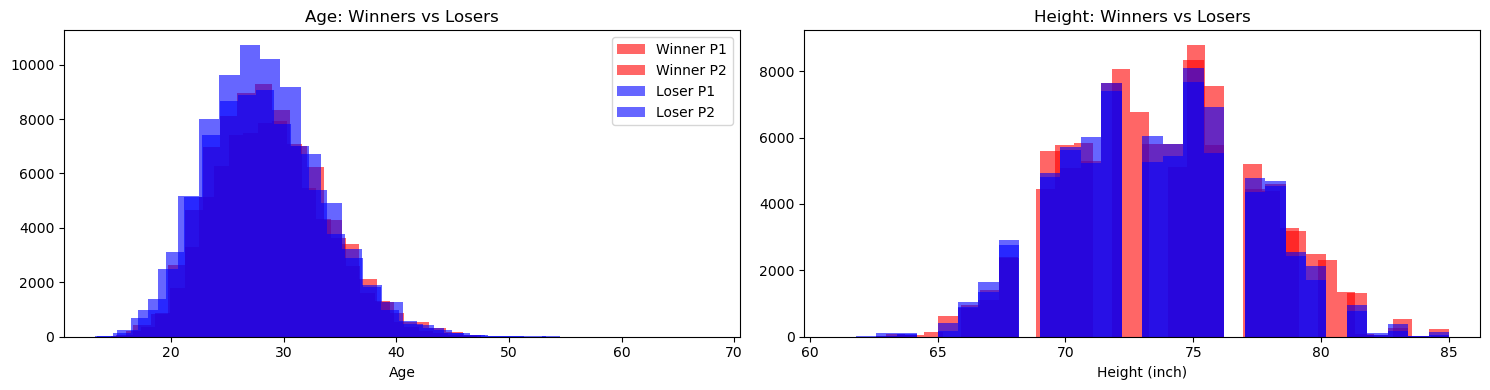

In [95]:
# visualise this for winning team and losing team
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# age 
axes[0].hist(df['w_p1_age'].dropna(), bins=30, alpha=0.6, label='Winner P1', color='red')
axes[0].hist(df['w_p2_age'].dropna(), bins=30, alpha=0.6, label='Winner P2', color='red')
axes[0].hist(df['l_p1_age'].dropna(), bins=30, alpha=0.6, label='Loser P1', color='blue')
axes[0].hist(df['l_p2_age'].dropna(), bins=30, alpha=0.6, label='Loser P2', color='blue')
axes[0].set_title('Age: Winners vs Losers')
axes[0].set_xlabel('Age')
axes[0].legend()

# height 
axes[1].hist(df['w_p1_hgt'].dropna(), bins=30, alpha=0.6, label='Winner P1', color='red')
axes[1].hist(df['w_p2_hgt'].dropna(), bins=30, alpha=0.6, label='Winner P2', color='red')
axes[1].hist(df['l_p1_hgt'].dropna(), bins=30, alpha=0.6, label='Loser P1', color='blue')
axes[1].hist(df['l_p2_hgt'].dropna(), bins=30, alpha=0.6, label='Loser P2', color='blue')
axes[1].set_title('Height: Winners vs Losers')
axes[1].set_xlabel('Height (inch)')

plt.tight_layout()
plt.show()

Age distributions are almost identical, winners have slighly higher heights 

I tried to make a rank graph, but the x axis label threw errors bcs rank is actually a string, so we need to convert rank to a number to quantify it. lets see what actually is in the rank column.

In [96]:
# rank
print(df['w_rank'].dtype)
print(df['l_rank'].dtype)
print(df['w_rank'].head(10))

print('\nlast 20 values:')
print(df['w_rank'].value_counts().tail(50))

# check for zeros
print(f"\nZero values in w_rank: {(df['w_rank'] == 0).sum()}")
print(f"Zero values in l_rank: {(df['l_rank'] == 0).sum()}")

object
object
0     1
1    16
2    24
3     8
4     5
5    12
6    13
7     4
8     3
9    14
Name: w_rank, dtype: object

last 20 values:
w_rank
53, Q20    2
47, Q25    2
14, Q13    2
57, Q36    2
25, Q24    2
64, Q36    2
51, Q3     2
17, Q8     2
19, Q16    2
37, Q11    2
50, Q6     2
56, Q34    2
61, Q17    2
Q106       1
36, Q14    1
34, Q5     1
41, Q9     1
35, Q7     1
Q95        1
Q93        1
59, Q14    1
57, Q12    1
34, Q14    1
7, Q7      1
52, Q5     1
55, Q9     1
35, Q5     1
37, Q4     1
33, Q11    1
36, Q19    1
40, Q13    1
45, Q16    1
43, Q7     1
35, Q11    1
47, Q19    1
34, Q8     1
8, Q8      1
40, Q9     1
Q90        1
1, Q7      1
Q102       1
8, Q7      1
6, Q5      1
48, Q1     1
50, Q2     1
32, Q1     1
44, Q6     1
45, Q7     1
49, Q1     1
43, Q10    1
Name: count, dtype: int64

Zero values in w_rank: 0
Zero values in l_rank: 0


Soooo the rank values are strings because they are either just the normal rank, a qualifier rank (e.g. Q101) or a normal rank and a qualifier rank (e.g. 32, Q1)

This might be useful information so we can extract a feature out of it - 1) extract actual rank 2) extract qualifying rank

In [97]:
def extract_main_rank(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).strip()
    # only a qualifier rank
    if val_str.startswith('Q'):
        return np.nan
    # has both ("8, Q7") or just a number ("5")
    return pd.to_numeric(val_str.split(',')[0].strip(), errors='coerce')

def extract_qualifier_rank(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).strip()
    if 'Q' in val_str:
        q_part = val_str.split('Q')[-1].strip()
        return pd.to_numeric(q_part, errors='coerce')
    return np.nan

In [98]:
df['w_main_rank'] = df['w_rank'].apply(extract_main_rank)
df['w_qualifier_rank'] = df['w_rank'].apply(extract_qualifier_rank)

df['l_main_rank'] = df['l_rank'].apply(extract_main_rank)
df['l_qualifier_rank'] = df['l_rank'].apply(extract_qualifier_rank)


In [99]:
# verify split, same number of values
print("main and qualifier rank values:")
print(f"w_main: {df['w_main_rank'].count()}")
print(f"l_main: {df['l_main_rank'].count()}")
print(f"w_qualifier: {df['w_qualifier_rank'].count()}")
print(f"l_qualifier: {df['l_qualifier_rank'].count()}")

# intersection - both main and qualifier are non-null values
both_w = df['w_main_rank'].notna() & df['w_qualifier_rank'].notna()
print(f"w_intersection: {both_w.sum()}")
both_l = df['l_main_rank'].notna() & df['l_qualifier_rank'].notna()
print(f"l_intersection: {both_l.sum()}")

print("\ntotal number of non-zero values from the initial rank feature:")
print(f"w_rank: {df['w_rank'].count()}")
print(f"l_rank: {df['l_rank'].count()}")

main and qualifier rank values:
w_main: 64869
l_main: 53440
w_qualifier: 30063
l_qualifier: 35478
w_intersection: 18324
l_intersection: 13402

total number of non-zero values from the initial rank feature:
w_rank: 76608
l_rank: 75516


If you do n(A) + n(B) - n(A and B) = n(total non-zero initially in C), it is consistent!!! so we have successfully split the rank feature into a main rank and a qualifier rank feature!

<h3>Baseline model:</h3>
<p>Now that we have nice rank features, we can make a baseline prediction based on who just has the higher main rank, or if neither of the teams have main ranks, then qualifier ranks.</p>
<p>Calculating the accuracy of the baseline: </p>

In [100]:
# if both teams have a main rank:
both_main = df[df['w_main_rank'].notna() & df['l_main_rank'].notna()]
higher_ranked_won = both_main['w_main_rank'] < both_main['l_main_rank'] # returns a list of True or False (1 or 0)

print(f"both teams have main")
print(f"Total matches: {len(both_main)}") 
print(f"Higher ranked team won: {higher_ranked_won.mean():.2%}") 
# the mean is the number of trues / total = higher_team_won pct

both teams have main
Total matches: 53375
Higher ranked team won: 70.09%


In [101]:
# if both teams have a qualifying rank and no main ranks:
both_qualifier = df[df['w_main_rank'].isna() & df['l_main_rank'].isna() & 
                    df['w_qualifier_rank'].notna() & df['l_qualifier_rank'].notna()]
higher_qualifier_won = both_qualifier['w_qualifier_rank'] < both_qualifier['l_qualifier_rank']

print(f"both teams have qualifier only")
print(f"Total matches: {len(both_qualifier)}")
print(f"Higher qualifier ranked team won: {higher_qualifier_won.mean():.2%}")

both teams have qualifier only
Total matches: 11006
Higher qualifier ranked team won: 67.27%


In [102]:
# you can't really compare a main rank to a qualifying rank without making assumptions, so we will just leave it
# but i still want to see if having a general rank gives you a statistically better chance then only having a qualifier rank

winner_main_only = df[df['w_main_rank'].notna() & df['l_main_rank'].isna() &
                      df['w_qualifier_rank'].isna() & df['l_qualifier_rank'].notna()]
loser_main_only = df[df['l_main_rank'].notna() & df['w_main_rank'].isna() & 
                     df['l_qualifier_rank'].isna() & df['w_qualifier_rank'].notna()]

total_mixed = len(winner_main_only) + len(loser_main_only)
main_rank_team_won = len(winner_main_only) / total_mixed
print(f"Total matches: {total_mixed}")
print(f"Team with a general rank won: {main_rank_team_won:.2%}")

Total matches: 7
Team with a general rank won: 71.43%


BASELINE

Predicting based on general ranks has 70% accuracy

Predicting based on qualifier ranks has 67% accuracy

In matches where A has general rank only and B has qualifier rank only, A wins 71% of the time. this could be a correlation, but as there are only 7 total matches, the cases where this occurs is very few, so imo we'd need a larger dataset to confirm.

<h3>Exploring cont.</h3>

bcs I still need to look at competition info: duration, score, match, round, bracket, etc

In [103]:
df['duration'].head

<bound method NDFrame.head of 0        00:33:00
1        00:57:00
2        00:46:00
3        00:44:00
4        01:08:00
           ...   
76751    00:34:00
76752    00:48:00
76753    00:40:00
76754    00:41:00
76755    00:33:00
Name: duration, Length: 76756, dtype: object>

So duration is a string that we need to convert to number of minutes

In [104]:
def convert_duration(val):
    if pd.isna(val):
        return np.nan
    try:
        parts = str(val).strip().split(':')
        hours = int(parts[0])
        minutes = int(parts[1])
        seconds = int(parts[2])
        total_minutes = hours * 60 + minutes + seconds / 60
        return round(total_minutes, 2)
    except:
        return np.nan

In [105]:
df['duration'] = df['duration'].apply(convert_duration)

In [106]:
print(df['duration'].describe())

count    74507.000000
mean        43.922907
std         10.953282
min          2.000000
25%         36.000000
50%         42.000000
75%         51.000000
max        134.000000
Name: duration, dtype: float64


The count matches up with the number of values we saw initially for duration (74507), so everything has gone fine and no duration values have been lost in the process of conversion

In [107]:
# other comp info
game_info_cols = ['circuit', 'tournament', 'country', 'year', 'date', 'gender', 'bracket', 'round', 'match_num', 'duration']
for col in game_info_cols:
    print(df[col].value_counts().head(10))
    print(f"unique values: {df[col].nunique()}\n")

circuit
FIVB    51403
AVP     25353
Name: count, dtype: int64
unique values: 2

tournament
Gstaad              3766
Manhattan Beach     3506
Huntington Beach    2967
Hermosa Beach       2735
Klagenfurt          2608
Stavanger           2551
Chicago             2309
Moscow              2077
Shanghai            1887
Berlin              1800
Name: count, dtype: int64
unique values: 177

country
United States    27311
China             6158
Switzerland       4116
Poland            3358
Russia            3318
Austria           3302
Norway            3280
France            2567
Germany           2297
Brazil            2070
Name: count, dtype: int64
unique values: 51

year
2018    6293
2007    5845
2008    5426
2019    5406
2006    5351
2005    5235
2009    4724
2004    4310
2015    4005
2010    3863
Name: count, dtype: int64
unique values: 20

date
2018-07-26    401
2019-08-15    369
2009-07-16    357
2019-07-25    303
2017-08-17    279
2006-08-10    278
2006-06-09    273
2018-08-16    269
2

Bracket qualitatively describes the importance of the match (e.g. pool match vs finals), round numerically counts what round it is in the tournament and also signals importance/stakes (the higher the round, the fewer people make it), and the match number just numbers each of the matches in a tournament (and is arbitrary, so we can drop it).

Bracket is important: In AVP, the order is Qualifiers --> Pool --> Contenders --> Winners --> Semis --> Finals. There might also be quarterfinals and etc.

There are 10 unique rounds total, but we do not know if sometimes some tournaments have <10 rounds. Rounds and brackets are related, but the brackets won't all be consistent across each competition if different comps have different naming conventions. Also, we have to remove the string "Round" if we just want the round number.

Want to see if:
- higher ranked teams win less often in higher brackets/further rounds bcs pressure
- further rounds have longer duration

In [108]:
# come back to this
df['higher_ranked_won'] = np.where(
    df['w_main_rank'].notna() & df['l_main_rank'].notna(),
    df['w_main_rank'] < df['l_main_rank'],
    np.nan
)

bracket_analysis = df.groupby('bracket').agg(
    total_matches=('higher_ranked_won', 'count'),
    winning_pct =('higher_ranked_won', lambda x: x.mean())
).sort_values('winning_pct')

print("Winning % in each bracket:")
print(bracket_analysis[bracket_analysis['total_matches'] > 100])

Winning % in each bracket:
                     total_matches  winning_pct
bracket                                        
Qualifier Bracket              290     0.417241
Pool H                        1659     0.603978
Pool P                         126     0.611111
Gold Medal                     649     0.624037
Bronze Medal                   647     0.627512
Pool Q                         120     0.633333
Semifinals                    1945     0.672494
Contender's Bracket          11682     0.673943
Pool M                         156     0.679487
Pool G                        1660     0.680723
Pool F                        1805     0.691413
Pool E                        1803     0.701608
Pool K                         233     0.703863
Pool D                        2124     0.710923
Pool C                        2133     0.711205
Finals                         330     0.721212
Winner's Bracket             20725     0.723474
Pool L                         234     0.739316
Pool O       

In [109]:
# come back to this
round_analysis = df.groupby('round').agg(
    total_matches=('higher_ranked_won', 'count'),
    winning_rate=('higher_ranked_won', lambda x: x.mean())
).sort_values('winning_rate')

print("Winning% in each round:")
print(round_analysis)

Winning% in each round:
          total_matches  winning_rate
round                                
Round 10              7      0.428571
Round 8               4      0.500000
Round 5             845      0.644970
Round 6             632      0.662975
Round 4            2470      0.670850
Round 3            9260      0.678726
Round 2           16438      0.710731
Round 1           20074      0.717695
Round 7              23      0.782609
Round 9               0           NaN


the higher ranked team seems to win less often in further matches, but also only using general ranks 

In [110]:
# come back to this
round_duration = df.groupby('round').agg(
    total_matches=('duration', 'count'),
    avg_duration=('duration', 'mean')
).round(1).sort_values('avg_duration')

print("\n=== Average Duration by Round ===")
print(round_duration)


=== Average Duration by Round ===
          total_matches  avg_duration
round                                
Round 9              19          41.1
Round 7              82          41.6
Round 8              43          41.7
Round 1           28323          42.5
Round 2           24739          43.5
Round 3           11777          45.2
Round 10             18          45.3
Round 6             687          47.9
Round 5             893          48.3
Round 4            3099          48.4


The rounds don't seem to get longer as they go on, there is no correlation between round number and duration

In [111]:
df = df.drop(columns='higher_ranked_won')

<h1>2 - Cleaning Data and Feature Engineering</h1>

not missing
- circuit, tournament, country, year, date, gender, match num, bracket (score, duration, round are missing some values, but its very few)

filling in miss values
- keep game stats as they are, model can handle the null value
- fill in missing player age with median age, grouped by same gender and circuit (FIVB and AVP for different skill/age of athletes)
- fill in missing player height with median height, grouped by same gender
- don't worry about filling in player 1 and 2 country, very small missing
- restructure w_,l_ to Team A and Team B format, then add column of 1s for A winning, then flip 50% of the data randomly

feature engineering
- encode categorical features (circuit, tournament, country, gender, bracket)
- home country advantage
- error pct in game stats
- drop columns we don't need
- scale the data with standard scaler

In [112]:
df.columns

Index(['circuit', 'tournament', 'country', 'year', 'date', 'gender',
       'match_num', 'w_player1', 'w_p1_birthdate', 'w_p1_age', 'w_p1_hgt',
       'w_p1_country', 'w_player2', 'w_p2_birthdate', 'w_p2_age', 'w_p2_hgt',
       'w_p2_country', 'w_rank', 'l_player1', 'l_p1_birthdate', 'l_p1_age',
       'l_p1_hgt', 'l_p1_country', 'l_player2', 'l_p2_birthdate', 'l_p2_age',
       'l_p2_hgt', 'l_p2_country', 'l_rank', 'score', 'duration', 'bracket',
       'round', 'w_p1_tot_attacks', 'w_p1_tot_kills', 'w_p1_tot_errors',
       'w_p1_tot_hitpct', 'w_p1_tot_aces', 'w_p1_tot_serve_errors',
       'w_p1_tot_blocks', 'w_p1_tot_digs', 'w_p2_tot_attacks',
       'w_p2_tot_kills', 'w_p2_tot_errors', 'w_p2_tot_hitpct', 'w_p2_tot_aces',
       'w_p2_tot_serve_errors', 'w_p2_tot_blocks', 'w_p2_tot_digs',
       'l_p1_tot_attacks', 'l_p1_tot_kills', 'l_p1_tot_errors',
       'l_p1_tot_hitpct', 'l_p1_tot_aces', 'l_p1_tot_serve_errors',
       'l_p1_tot_blocks', 'l_p1_tot_digs', 'l_p2_tot_attacks',


In [113]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(missing_df.sort_values('missing_%'))

                       missing_count  missing_%
circuit                            0        0.0
l_p2_country                      10        0.0
l_player2                          0        0.0
l_p1_country                      18        0.0
bracket                            0        0.0
l_player1                          0        0.0
w_p2_country                       5        0.0
w_player2                          0        0.0
w_p1_country                      12        0.0
score                             22        0.0
w_player1                          0        0.0
tournament                         0        0.0
match_num                          0        0.0
gender                             0        0.0
date                               0        0.0
year                               0        0.0
country                            0        0.0
w_rank                           148        0.2
w_p2_age                         408        0.5
w_p1_birthdate                   383    

<h3>Age</h3>

fill in missing values with median age grouped by height and circuit

only a small portion of age values are missing (0.5), so keep it simple

In [114]:
# check (for later)
print(f"\nages < 16: {(df[['w_p1_age', 'w_p2_age', 'l_p1_age', 'l_p2_age']] < 16).sum().sum()}")
print(f"ages > 45: {(df[['w_p1_age', 'w_p2_age', 'l_p1_age', 'l_p2_age']] > 45).sum().sum()}")


ages < 16: 255
ages > 45: 737


In [115]:
print(df.groupby(['gender', 'circuit'])[['w_p1_age', 'w_p2_age', 'l_p1_age', 'l_p2_age']].median())
# this groups each age value by gender and circuit, and calculates the median age of each group

                 w_p1_age   w_p2_age   l_p1_age   l_p2_age
gender circuit                                            
M      AVP      30.469541  30.171116  30.308008  29.921971
       FIVB     28.213552  28.585900  27.731691  27.957563
W      AVP      29.029432  29.381246  28.829569  28.843258
       FIVB     26.744695  27.342916  26.316222  26.614648


In [116]:
for column in ['w_p1_age', 'w_p2_age', 'l_p1_age', 'l_p2_age']:
    median_age_df = df.groupby(['gender', 'circuit'])[column].transform('median')
    
    if df[column].isnull:
        df[column] = df[column].fillna(median_age_df)

In [117]:
df['w_p1_age']

0        29.694730
1        27.356605
2        31.203285
3        32.386037
4        32.054757
           ...    
76751    23.734428
76752    22.154689
76753    23.734428
76754    25.467488
76755    22.154689
Name: w_p1_age, Length: 76756, dtype: float64

In [118]:
print(df[['w_p1_age', 'w_p2_age', 'l_p1_age', 'l_p2_age']].isnull().sum())

w_p1_age    0
w_p2_age    0
l_p1_age    0
l_p2_age    0
dtype: int64


In [119]:
print(df[['w_p1_age', 'w_p2_age', 'l_p1_age', 'l_p2_age']].describe().round(2))
print(f"\nAges under 16: {(df[['w_p1_age', 'w_p2_age', 'l_p1_age', 'l_p2_age']] < 16).sum().sum()}")
print(f"Ages over 45: {(df[['w_p1_age', 'w_p2_age', 'l_p1_age', 'l_p2_age']] > 45).sum().sum()}")

       w_p1_age  w_p2_age  l_p1_age  l_p2_age
count  76756.00  76756.00  76756.00  76756.00
mean      28.73     28.83     28.33     28.37
std        5.04      4.83      5.22      5.09
min       13.55     13.41     13.23     13.41
25%       25.03     25.31     24.59     24.76
50%       28.34     28.60     27.94     28.00
75%       32.02     31.92     31.61     31.52
max       59.86     52.40     60.86     67.76

Ages under 16: 255
Ages over 45: 737


<h3>Height </h3>

fill in missing values with median height grouped by gender and age, need to bin ages

can't group by country because some countries have missing heights for all players from that country (shown below)

In [120]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(df.groupby(['gender', 'w_p1_country'])[['w_p1_hgt', 'w_p2_hgt']].median())
    print(df.groupby(['gender', 'l_p1_country'])[['l_p1_hgt', 'l_p2_hgt']].median())

                             w_p1_hgt  w_p2_hgt
gender w_p1_country                            
M      Andorra                   75.0      71.0
       Angola                    75.0      72.0
       Argentina                 76.0      73.0
       Australia                 78.0      75.0
       Austria                   75.0      76.0
       Azerbaijan                78.0      72.0
       Bahrain                   69.0      71.0
       Belarus                   74.0      77.0
       Belgium                   75.0      78.0
       Brazil                    76.0      76.0
       Bulgaria                  77.5      73.0
       Canada                    76.0      77.0
       Chile                     75.0      77.0
       China                     79.0      78.0
       Chinese Taipei            69.0      73.0
       Colombia                   NaN       NaN
       Costa Rica                75.0      74.0
       Croatia                   77.0      76.0
       Cuba                      72.0   

In [121]:
# bin ages
age_bins = [0, 20, 24, 28, 32, 36, 40, 44, 100]
age_labels = ['U20', '20-24', '24-28', '28-32', '32-36', '36-40', '40-44', '44+']

df['age_bins_temp'] = pd.cut(df['w_p1_age'], bins=age_bins, labels=age_labels)

In [122]:
print(df.groupby(['gender', 'age_bins_temp'])[['w_p1_hgt', 'w_p2_hgt', 'l_p1_hgt', 'l_p2_hgt']].median())

                      w_p1_hgt  w_p2_hgt  l_p1_hgt  l_p2_hgt
gender age_bins_temp                                        
M      U20                75.0      76.0      75.0      76.0
       20-24              76.0      76.0      76.0      76.0
       24-28              76.0      76.0      76.0      76.0
       28-32              76.0      76.0      76.0      76.0
       32-36              76.0      76.0      76.0      76.0
       36-40              76.0      77.0      76.0      76.0
       40-44              76.0      76.0      76.0      76.0
       44+                75.5      79.0      76.0      76.0
W      U20                72.0      71.0      70.0      70.0
       20-24              71.0      71.0      70.0      70.0
       24-28              71.0      71.0      71.0      71.0
       28-32              71.0      71.0      71.0      71.0
       32-36              71.0      71.0      71.0      71.0
       36-40              72.0      72.0      71.0      71.0
       40-44            

C:\Users\xinyue\AppData\Local\Temp\ipykernel_3264\1196684192.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(['gender', 'age_bins_temp'])[['w_p1_hgt', 'w_p2_hgt', 'l_p1_hgt', 'l_p2_hgt']].median())


In [123]:
for column in ['w_p1_hgt', 'w_p2_hgt', 'l_p1_hgt', 'l_p2_hgt']:
    median_hgt_df = df.groupby(['gender', 'age_bins_temp'])[column].transform('median')
    
    if df[column].isnull:
        df[column] = df[column].fillna(median_hgt_df)

C:\Users\xinyue\AppData\Local\Temp\ipykernel_3264\499559524.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_hgt_df = df.groupby(['gender', 'age_bins_temp'])[column].transform('median')
C:\Users\xinyue\AppData\Local\Temp\ipykernel_3264\499559524.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_hgt_df = df.groupby(['gender', 'age_bins_temp'])[column].transform('median')
C:\Users\xinyue\AppData\Local\Temp\ipykernel_3264\499559524.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current be

In [124]:
print(df[['w_p1_age', 'w_p2_age', 'l_p1_age', 'l_p2_age']].isnull().sum())

w_p1_age    0
w_p2_age    0
l_p1_age    0
l_p2_age    0
dtype: int64


In [125]:
df = df.drop(columns='age_bins_temp')

In [126]:
print(df[['w_p1_hgt', 'w_p2_hgt', 'l_p1_hgt', 'l_p2_hgt']].describe().round(2))

       w_p1_hgt  w_p2_hgt  l_p1_hgt  l_p2_hgt
count  76756.00  76756.00  76756.00  76756.00
mean      73.72     73.75     73.43     73.56
std        3.58      3.64      3.55      3.57
min       63.00     61.00     61.00     61.00
25%       71.00     71.00     71.00     71.00
50%       74.00     74.00     73.00     74.00
75%       76.00     76.00     76.00     76.00
max       85.00     85.00     85.00     85.00


<h3>Encoding categorical features</h3>

binary encode: circuit, gender

manually encode: bracket, round

frequency encode: country, tournament (bcs some are very famous and increase stakes)

don't encode: w_p1_age/p2/lp1/lp2, w_p1_hgt/p2/lp1/lp2, game_stats, main_rank, qualifier_rank, year

dropping: match num, date, player names, player birthdates, og ranks, score, duration, player_country (but engineer a feature about home country advantage)

In [127]:
# binary encoding 
print(df['gender'].value_counts())
print(df['circuit'].value_counts())

df['gender'] = (df['gender'] == 'W').astype(int)
df['circuit'] = (df['circuit'] == 'FIVB').astype(int)

gender
M    40270
W    36486
Name: count, dtype: int64
circuit
FIVB    51403
AVP     25353
Name: count, dtype: int64


In [128]:
print(df['gender'].value_counts())
print(df['circuit'].value_counts())

gender
0    40270
1    36486
Name: count, dtype: int64
circuit
1    51403
0    25353
Name: count, dtype: int64


In [129]:
df.columns

Index(['circuit', 'tournament', 'country', 'year', 'date', 'gender',
       'match_num', 'w_player1', 'w_p1_birthdate', 'w_p1_age', 'w_p1_hgt',
       'w_p1_country', 'w_player2', 'w_p2_birthdate', 'w_p2_age', 'w_p2_hgt',
       'w_p2_country', 'w_rank', 'l_player1', 'l_p1_birthdate', 'l_p1_age',
       'l_p1_hgt', 'l_p1_country', 'l_player2', 'l_p2_birthdate', 'l_p2_age',
       'l_p2_hgt', 'l_p2_country', 'l_rank', 'score', 'duration', 'bracket',
       'round', 'w_p1_tot_attacks', 'w_p1_tot_kills', 'w_p1_tot_errors',
       'w_p1_tot_hitpct', 'w_p1_tot_aces', 'w_p1_tot_serve_errors',
       'w_p1_tot_blocks', 'w_p1_tot_digs', 'w_p2_tot_attacks',
       'w_p2_tot_kills', 'w_p2_tot_errors', 'w_p2_tot_hitpct', 'w_p2_tot_aces',
       'w_p2_tot_serve_errors', 'w_p2_tot_blocks', 'w_p2_tot_digs',
       'l_p1_tot_attacks', 'l_p1_tot_kills', 'l_p1_tot_errors',
       'l_p1_tot_hitpct', 'l_p1_tot_aces', 'l_p1_tot_serve_errors',
       'l_p1_tot_blocks', 'l_p1_tot_digs', 'l_p2_tot_attacks',


manually encode round and bracket, as they have meaning

In [130]:
# manual encoding
df['round'].value_counts()

round
Round 1     29090
Round 2     25463
Round 3     12256
Round 4      3223
Round 5       906
Round 6       710
Round 7        85
Round 8        44
Round 9        20
Round 10       20
Name: count, dtype: int64

In [131]:
round_labels = {
    "Round 1": 1,
    "Round 2": 2,
    "Round 3": 3,
    "Round 4": 4,
    "Round 5": 5,
    "Round 6": 6,
    "Round 7": 7,
    "Round 8": 8,
    "Round 9": 9,
    "Round 10": 10
}

In [132]:
df['bracket'].value_counts()

bracket
Qualifier Bracket        22245
Winner's Bracket         20726
Contender's Bracket      11686
Pool A                    2212
Pool B                    2193
Pool C                    2139
Pool D                    2130
Semifinals                1950
Pool F                    1805
Pool E                    1803
Pool G                    1660
Pool H                    1659
Country Quota Matches     1241
Gold Medal                 651
Bronze Medal               649
Finals                     337
Pool L                     234
Pool J                     234
Pool K                     233
Pool M                     156
Pool N                     126
Pool O                     126
Pool P                     126
Pool Q                     120
Pool I                      84
Qualifier Playoff           70
Pool X                      42
Pool Y                      42
Lucky Losers                37
Pool T                       6
Pool V                       6
Pool U                       6


research
- country quota is when two teams from the same nation compete to enter the main pool matches 
- lucky losers is when you have another chance to enter the main match again
- winners bracket is everyone who didn't lose in pool, now compete against each other
- contendors are people who lost only once in pool and now compete against each other - if you lose 2 times you're out

In [133]:
bracket_labels = {
    "Qualifier Bracket": 1, "Qualifier Playoff": 1, "Lucky Losers": 1, "Country Quota Matches": 1,
    "Pool A": 2, "Pool B": 2, "Pool C": 2, "Pool D": 2, "Pool E": 2, "Pool F": 2, "Pool G": 2, "Pool H": 2, "Pool I": 2, 
    "Pool J": 2, "Pool K": 2, "Pool L": 2, "Pool M": 2, "Pool N": 2, "Pool O": 2, "Pool P": 2, "Pool Q": 2, "Pool R": 2,
    "Pool S": 2, "Pool T": 2, "Pool U": 2, "Pool V": 2, "Pool W": 2, "Pool X": 2, "Pool Y": 2,
    "Contender's Bracket": 3, 
    "Winner's Bracket": 4,
    "Semifinals": 5, "Bronze Medal": 5, "3rd Place": 5,
    "Gold Medal": 6, "Finals": 6
}
len(bracket_labels)

36

In [134]:
df['round_encoded'] = df['round'].map(round_labels)
df['bracket_encoded'] = df['bracket'].map(bracket_labels)

print(df[['round', 'round_encoded']].value_counts())
print(f"\n{df[['bracket', 'bracket_encoded']].value_counts()}")

round     round_encoded
Round 1   1.0              29090
Round 2   2.0              25463
Round 3   3.0              12256
Round 4   4.0               3223
Round 5   5.0                906
Round 6   6.0                710
Round 7   7.0                 85
Round 8   8.0                 44
Round 10  10.0                20
Round 9   9.0                 20
Name: count, dtype: int64

bracket                bracket_encoded
Qualifier Bracket      1                  22245
Winner's Bracket       4                  20726
Contender's Bracket    3                  11686
Pool A                 2                   2212
Pool B                 2                   2193
Pool C                 2                   2139
Pool D                 2                   2130
Semifinals             5                   1950
Pool F                 2                   1805
Pool E                 2                   1803
Pool G                 2                   1660
Pool H                 2                   1659
Coun

In [135]:
# frequency encode country, tournament
country_frequency = (df['country'].value_counts() / len(df))
tournament_frequency = (df['tournament'].value_counts() / len(df))

In [136]:
# before
print(df['country'].value_counts())
print(f"\n{df['tournament'].value_counts()}")

country
United States             27311
China                      6158
Switzerland                4116
Poland                     3358
Russia                     3318
Austria                    3302
Norway                     3280
France                     2567
Germany                    2297
Brazil                     2070
Italy                      1957
Netherlands                1686
Portugal                   1508
Spain                      1439
Croatia                    1115
Japan                      1051
Czech Republic              995
Greece                      905
Turkey                      897
Thailand                    811
Mexico                      717
Australia                   713
South Africa                543
Korea                       467
Qatar                       433
Malaysia                    344
Iran                        299
Slovenia                    236
Cambodia                    230
Singapore                   212
Morocco                     198


In [137]:
df['country_encoded'] = df['country'].map(country_frequency)
df['tournament_encoded'] = df['tournament'].map(tournament_frequency)

In [138]:
# after
print(df['country_encoded'].value_counts())
print(f"\n{df['tournament_encoded'].value_counts()}")

country_encoded
0.355816    27311
0.080228     6158
0.053624     4116
0.043749     3358
0.043228     3318
0.043019     3302
0.042733     3280
0.033444     2567
0.029926     2297
0.026969     2070
0.025496     1957
0.021966     1686
0.019647     1508
0.018748     1439
0.014527     1115
0.013693     1051
0.012963      995
0.011791      905
0.011686      897
0.010566      811
0.009341      717
0.009289      713
0.007074      543
0.006084      467
0.005641      433
0.004482      344
0.002045      314
0.003895      299
0.003075      236
0.002997      230
0.002762      212
0.002580      198
0.002567      197
0.002371      182
0.002267      174
0.002254      173
0.000951      146
0.001785      137
0.001772      136
0.001616      124
0.001407      108
0.001329      102
0.001290       99
0.000990       76
0.000899       69
0.000860       66
0.000834       64
0.000521       40
0.000208       16
Name: count, dtype: int64

tournament_encoded
0.049065    3766
0.045677    3506
0.038655    2967
0.035

<h3>Feature Engineering</h3>

home-country advantage, error ratio in game stats


In [139]:
# home country advantage
df['w_home_adv'] = ((df['w_p1_country'] == df['country']) | (df['w_p2_country'] == df['country'])).astype(int)
df['l_home_adv'] = ((df['l_p1_country'] == df['country']) | (df['l_p2_country'] == df['country'])).astype(int)

In [140]:
print(df['w_home_adv'].value_counts())
print(df['l_home_adv'].value_counts())
print(df['w_home_adv'].head())
print(df[['country', 'w_p1_country']].head(5))

w_home_adv
0    47434
1    29322
Name: count, dtype: int64
l_home_adv
0    45288
1    31468
Name: count, dtype: int64
0    1
1    1
2    0
3    1
4    1
Name: w_home_adv, dtype: int32
         country   w_p1_country
0  United States  United States
1  United States  United States
2  United States         Brazil
3  United States  United States
4  United States  United States


In [141]:
# error ratio = errors / attacks (how many errors per attack, instability)
df.columns

Index(['circuit', 'tournament', 'country', 'year', 'date', 'gender',
       'match_num', 'w_player1', 'w_p1_birthdate', 'w_p1_age', 'w_p1_hgt',
       'w_p1_country', 'w_player2', 'w_p2_birthdate', 'w_p2_age', 'w_p2_hgt',
       'w_p2_country', 'w_rank', 'l_player1', 'l_p1_birthdate', 'l_p1_age',
       'l_p1_hgt', 'l_p1_country', 'l_player2', 'l_p2_birthdate', 'l_p2_age',
       'l_p2_hgt', 'l_p2_country', 'l_rank', 'score', 'duration', 'bracket',
       'round', 'w_p1_tot_attacks', 'w_p1_tot_kills', 'w_p1_tot_errors',
       'w_p1_tot_hitpct', 'w_p1_tot_aces', 'w_p1_tot_serve_errors',
       'w_p1_tot_blocks', 'w_p1_tot_digs', 'w_p2_tot_attacks',
       'w_p2_tot_kills', 'w_p2_tot_errors', 'w_p2_tot_hitpct', 'w_p2_tot_aces',
       'w_p2_tot_serve_errors', 'w_p2_tot_blocks', 'w_p2_tot_digs',
       'l_p1_tot_attacks', 'l_p1_tot_kills', 'l_p1_tot_errors',
       'l_p1_tot_hitpct', 'l_p1_tot_aces', 'l_p1_tot_serve_errors',
       'l_p1_tot_blocks', 'l_p1_tot_digs', 'l_p2_tot_attacks',


In [142]:
df['w_error_ratio'] = np.where((df['w_p1_tot_attacks'] + df['w_p2_tot_attacks']) > 0,
                              (df['w_p1_tot_errors'] + df['w_p2_tot_errors']) / (df['w_p1_tot_attacks'] + df['w_p2_tot_attacks']),
                              np.nan)

df['l_error_ratio'] = np.where((df['l_p1_tot_attacks'] + df['l_p2_tot_attacks']) > 0,
                              (df['l_p1_tot_errors'] + df['l_p2_tot_errors']) / (df['l_p1_tot_attacks'] + df['l_p2_tot_attacks']),
                              np.nan)

In [143]:
print(df['w_error_ratio'].describe())
print(df['l_error_ratio'].describe())

print(df['w_error_ratio'].mean())
print(df['l_error_ratio'].mean())

count    14334.000000
mean         0.110043
std          0.054517
min          0.000000
25%          0.075000
50%          0.107143
75%          0.140845
max          0.763636
Name: w_error_ratio, dtype: float64
count    14329.000000
mean         0.166751
std          0.077522
min          0.000000
25%          0.121622
50%          0.162162
75%          0.206897
max          4.333333
Name: l_error_ratio, dtype: float64
0.11004305761058472
0.16675083472659122


In [144]:
# positive offensive/defensive plays
df['w_contribution'] = np.where((df['w_p1_tot_attacks'] + df['w_p2_tot_attacks']) > 0,
                               (df['w_p1_tot_aces'] + df['w_p1_tot_blocks'] + df['w_p1_tot_digs'] + df['w_p2_tot_aces'] + df['w_p2_tot_blocks'] + df['w_p2_tot_digs']) /
                               (df['w_p1_tot_attacks'] + df['w_p2_tot_attacks']),
                               np.nan)
df['l_contribution'] = np.where((df['l_p1_tot_attacks'] + df['l_p2_tot_attacks']) > 0,
                               (df['l_p1_tot_aces'] + df['l_p1_tot_blocks'] + df['l_p1_tot_digs'] + df['l_p2_tot_aces'] + df['l_p2_tot_blocks'] + df['l_p2_tot_digs']) /
                               (df['l_p1_tot_attacks'] + df['l_p2_tot_attacks']),
                               np.nan)

In [145]:
print(df['w_contribution'].mean())
print(df['l_contribution'].mean())

0.4519230009460178
0.32923806981800235


<h3>Final Data Restructuring</h3>

drop all unwanted columns

restructure into team A, team B, flip 50% so there's not a biased skew

In [146]:
# dropping
drop_columns = ['tournament', 'country', 'date', 'match_num',
               'w_player1', 'w_p1_birthdate', 'w_p1_country',
               'w_player2', 'w_p2_birthdate', 'w_p2_country',
               'l_player1', 'l_p1_birthdate', 'l_p1_country',
               'l_player2', 'l_p2_birthdate', 'l_p2_country',
               'w_rank', 'l_rank',
               'score', 'duration', 'bracket', 'round',
               'w_p1_tot_aces', 'w_p1_tot_digs', 'w_p1_tot_blocks',
               'w_p2_tot_aces', 'w_p2_tot_digs', 'w_p2_tot_blocks',
               'l_p1_tot_aces', 'l_p1_tot_digs', 'l_p1_tot_blocks',
               'l_p2_tot_aces', 'l_p2_tot_digs', 'l_p2_tot_blocks']

# match num, date, player names, player birthdates, og ranks, score, duration, player_country

In [147]:
df.drop(columns=drop_columns, inplace=True)

In [148]:
print(df.columns)
print(df.head(5))

Index(['circuit', 'year', 'gender', 'w_p1_age', 'w_p1_hgt', 'w_p2_age',
       'w_p2_hgt', 'l_p1_age', 'l_p1_hgt', 'l_p2_age', 'l_p2_hgt',
       'w_p1_tot_attacks', 'w_p1_tot_kills', 'w_p1_tot_errors',
       'w_p1_tot_hitpct', 'w_p1_tot_serve_errors', 'w_p2_tot_attacks',
       'w_p2_tot_kills', 'w_p2_tot_errors', 'w_p2_tot_hitpct',
       'w_p2_tot_serve_errors', 'l_p1_tot_attacks', 'l_p1_tot_kills',
       'l_p1_tot_errors', 'l_p1_tot_hitpct', 'l_p1_tot_serve_errors',
       'l_p2_tot_attacks', 'l_p2_tot_kills', 'l_p2_tot_errors',
       'l_p2_tot_hitpct', 'l_p2_tot_serve_errors', 'w_main_rank',
       'w_qualifier_rank', 'l_main_rank', 'l_qualifier_rank', 'round_encoded',
       'bracket_encoded', 'country_encoded', 'tournament_encoded',
       'w_home_adv', 'l_home_adv', 'w_error_ratio', 'l_error_ratio',
       'w_contribution', 'l_contribution'],
      dtype='object')
   circuit  year  gender   w_p1_age  w_p1_hgt   w_p2_age  w_p2_hgt   l_p1_age  \
0        0  2002       0  29.69

In [149]:
# restructure
np.random.seed(42)
flipping_map = np.random.random(len(df)) < 0.5

In [150]:
w_columns = sorted([c for c in df.columns if c.startswith('w_')])
l_columns = sorted([c for c in df.columns if c.startswith('l_')])

column_pairs = []
for w_column in w_columns:
    l_column = w_column.replace('w_', 'l_', 1)
    if l_column in df.columns:
        column_pairs.append((w_column, l_column))

print(len(column_pairs))

19


In [151]:
new_df = df.copy()

for w_column, l_column in column_pairs:
    a_column = w_column.replace('w', 'a', 1)
    b_column = l_column.replace('l', 'b', 1)
    
    new_df[a_column] = np.where(flipping_map, df[l_column], df[w_column])
    new_df[b_column] = np.where(flipping_map, df[w_column], df[l_column])

new_df['team_a_won'] = (~flipping_map).astype(int)

new_df.drop(columns = [c for c in new_df.columns if c.startswith('w_') or c.startswith('l_')], inplace=True)

In [152]:
print(new_df['team_a_won'].mean())
print(new_df.shape)
print(new_df.columns)

0.5003517640314764
(76756, 46)
Index(['circuit', 'year', 'gender', 'round_encoded', 'bracket_encoded',
       'country_encoded', 'tournament_encoded', 'a_contribution',
       'b_contribution', 'a_error_ratio', 'b_error_ratio', 'a_home_adv',
       'b_home_adv', 'a_main_rank', 'b_main_rank', 'a_p1_age', 'b_p1_age',
       'a_p1_hgt', 'b_p1_hgt', 'a_p1_tot_attacks', 'b_p1_tot_attacks',
       'a_p1_tot_errors', 'b_p1_tot_errors', 'a_p1_tot_hitpct',
       'b_p1_tot_hitpct', 'a_p1_tot_kills', 'b_p1_tot_kills',
       'a_p1_tot_serve_errors', 'b_p1_tot_serve_errors', 'a_p2_age',
       'b_p2_age', 'a_p2_hgt', 'b_p2_hgt', 'a_p2_tot_attacks',
       'b_p2_tot_attacks', 'a_p2_tot_errors', 'b_p2_tot_errors',
       'a_p2_tot_hitpct', 'b_p2_tot_hitpct', 'a_p2_tot_kills',
       'b_p2_tot_kills', 'a_p2_tot_serve_errors', 'b_p2_tot_serve_errors',
       'a_qualifier_rank', 'b_qualifier_rank', 'team_a_won'],
      dtype='object')


In [153]:
new_df.head()

,circuit,year,gender,round_encoded,bracket_encoded,country_encoded,tournament_encoded,a_contribution,b_contribution,a_error_ratio,...,b_p2_tot_errors,a_p2_tot_hitpct,b_p2_tot_hitpct,a_p2_tot_kills,b_p2_tot_kills,a_p2_tot_serve_errors,b_p2_tot_serve_errors,a_qualifier_rank,b_qualifier_rank,team_a_won
0,0,2002,0,1.0,4,0.355816,0.038655,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,0,2002,0,1.0,4,0.355816,0.038655,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,0,2002,0,1.0,4,0.355816,0.038655,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,0,2002,0,1.0,4,0.355816,0.038655,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,0,2002,0,1.0,4,0.355816,0.038655,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [154]:
new_df.to_csv('beach_volleyball_processed.csv', index=False)

<h1>Model training </h1>

- split data into X and y
- split X and y data randomly into X_train, y_train and X_test, y_test (the official testing data) (using test_train_split)
- standard scale X_train and X_test
- then, split X_train into val_X and train_X (cross validation data) (using test_train_split)
- build model
- train
- best hyperparams, evaluate model
- run a final model with the best hyperparams, using X_test
- calculate accuracy score with y_test, make final predictions

In [155]:
# split into results and without results
df_without_results = new_df.drop('team_a_won', axis=1, inplace=False)
df_results = new_df['team_a_won']

print(df_without_results.shape)
print(df_results.shape)

(76756, 45)
(76756,)


In [156]:
# split into train and test (here assume we dk what y_test is, we will predict and then see how accurate our final mode is)
X_train, X_test, y_train, y_test = train_test_split(df_without_results, df_results, train_size = 0.9, random_state = RANDOM_STATE)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)

(69080, 45)
(69080,)
(7676, 45)


In [157]:
# scale (TRY WITHOUT SCALING AFTER)
# X_train = StandardScaler().fit_transform(X_train)
# X_test = StandardScaler().fit_transform(X_test)

In [158]:
# split X_train into training and validation data
train_X, val_X, train_y, val_y = train_test_split(X_train, y_train, train_size = 0.7, random_state = RANDOM_STATE)
print(train_X.shape)
print(train_y.shape)
print(val_X.shape)
print(val_y.shape)
print(f"target proportion: {sum(train_y) / len(train_y)}")

(48356, 45)
(48356,)
(20724, 45)
(20724,)
target proportion: 0.4974770452477459


In [159]:
# basic logistic regression model to start with

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

pipeline.fit(train_X, train_y)

# evaluate with val dataset
pred = pipeline.predict(val_X)
prob = pipeline.predict_proba(val_X)[:, 1]

accuracy = accuracy_score(val_y, pred>0.5)
auc = roc_auc_score(val_y, prob)

print(f"accuracy: {accuracy:.2%}")
print(f"AUROC: {auc:.2f}")
print("\nreport:")
print(classification_report(val_y, pred))

accuracy: 70.46%
AUROC: 0.78

report:
              precision    recall  f1-score   support

           0       0.70      0.71      0.71     10276
           1       0.71      0.70      0.70     10448

    accuracy                           0.70     20724
   macro avg       0.70      0.70      0.70     20724
weighted avg       0.70      0.70      0.70     20724



models:

baseline naive rank prediction: 70%

logistic regression: 70%

In [160]:
# xgboost model, used previously in kag titanic

model = XGBClassifier(
    random_state = RANDOM_STATE,
    eval_metric = 'logloss',
    enable_categorical = False
)

model.fit(train_X, train_y,
         eval_set = [(val_X, val_y)],
         verbose = False)

pred = model.predict(val_X)
prob = model.predict_proba(val_X)[:, 1]

accuracy = accuracy_score(val_y, pred>0.5)
auc = roc_auc_score(val_y, prob)

print(f"accuracy: {accuracy:.2%}")
print(f"AUROC: {auc:.2f}")
print("\nreport:")
print(classification_report(val_y, pred))

accuracy: 77.94%
AUROC: 0.87

report:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78     10276
           1       0.78      0.78      0.78     10448

    accuracy                           0.78     20724
   macro avg       0.78      0.78      0.78     20724
weighted avg       0.78      0.78      0.78     20724



In [169]:
# xgboost with hyperparameter tuning with hyperopt

space = {
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(1)),
    'max_depth': hp.quniform('max_depth', 1, 15, 1),
    'n_estimators': hp.quniform('n_estimators', 10, 200, 10),
    'gamma': hp.uniform('gamma', 0, 9),
    'reg_lambda' : hp.uniform('reg_lambda', 0.0, 1.0),
    'min_child_weight': hp.quniform('min_child_weight', 0, 10, 1),
    'subsample' : hp.uniform('subsample', 0, 1),
    'seed': 1
}

In [170]:
def objective(space):
    
    model = XGBClassifier(learning_rate = space['learning_rate'],
                          max_depth = int(space['max_depth']),
                          n_estimators = int(space['n_estimators']),
                          gamma = space['gamma'],
                          reg_lambda = space['reg_lambda'],
                          min_child_weight = int(space['min_child_weight']),
                          subsample = space['subsample'],
                          eval_metric='logloss',
                          early_stopping_rounds=10,
                          objective="binary:logistic")
    
    model.fit(train_X, train_y,
              eval_set=[(val_X, val_y)],
              verbose=False)
    
    pred = model.predict(val_X)
    prob = model.predict_proba(val_X)[:, 1]
    
    accuracy = accuracy_score(val_y, pred>0.5)
    auroc = roc_auc_score(val_y, prob)
    
    print("SCORE:", accuracy)
    return {'loss': -accuracy, 'status': STATUS_OK}

In [171]:
trials = Trials()

best_hyperparams = fmin(fn = objective,
                        space = space,
                        algo = tpe.suggest,
                        max_evals = 100,
                        trials = trials)

SCORE:                                                 
0.7647172360548157                                     
SCORE:                                                                            
0.7556938814900598                                                                
SCORE:                                                                            
0.7761049990349354                                                                
SCORE:                                                                            
0.774802161744837                                                                 
SCORE:                                                                            
0.6956186064466319                                                                
SCORE:                                                                            
0.6159525188187609                                                                
SCORE:                                                    

SCORE:                                                                             
0.7762015055008685                                                                 
SCORE:                                                                             
0.7681914688284115                                                                 
SCORE:                                                                             
0.7748986682107701                                                                 
SCORE:                                                                             
0.774657402045937                                                                  
SCORE:                                                                             
0.777504342790967                                                                  
SCORE:                                                                             
0.7692047867207102                                                          

0.7765392781316348                                                                 
SCORE:                                                                             
0.7757672264041691                                                                 
SCORE:                                                                             
0.7763462651997683                                                                 
100%|██████████| 100/100 [39:43<00:00, 23.84s/trial, best loss: -0.7809303223315962]


In [172]:
print(best_hyperparams)

{'gamma': 2.801844213746789, 'learning_rate': 0.1278077498795917, 'max_depth': 12.0, 'min_child_weight': 9.0, 'n_estimators': 70.0, 'reg_lambda': 0.9960060362721521, 'subsample': 0.8953320998754184}


In [108]:
print(best_hyperparams)

{'gamma': 1.109876240607559, 'learning_rate': 0.08881828852450607, 'max_depth': 8.0, 'min_child_weight': 2.0, 'n_estimators': 400.0}


In [173]:
final_model = XGBClassifier(gamma = best_hyperparams['gamma'], 
                            learning_rate = best_hyperparams['learning_rate'], 
                            max_depth = int(best_hyperparams['max_depth']), 
                            min_child_weight = int(best_hyperparams['min_child_weight']), 
                            n_estimators = int(best_hyperparams['n_estimators']),
                            reg_lambda = best_hyperparams['reg_lambda'],
                            subsample = best_hyperparams['subsample'],
                            verbosity = 1,
                            random_state = RANDOM_STATE,
                            early_stopping_rounds = 10)

final_model.fit(train_X, train_y, eval_set = [(val_X, val_y)])

[0]	validation_0-logloss:0.64932
[1]	validation_0-logloss:0.61493
[2]	validation_0-logloss:0.58754
[3]	validation_0-logloss:0.56524
[4]	validation_0-logloss:0.54694
[5]	validation_0-logloss:0.53160
[6]	validation_0-logloss:0.51874
[7]	validation_0-logloss:0.50785
[8]	validation_0-logloss:0.49855
[9]	validation_0-logloss:0.49092
[10]	validation_0-logloss:0.48371
[11]	validation_0-logloss:0.47733
[12]	validation_0-logloss:0.47223
[13]	validation_0-logloss:0.46761
[14]	validation_0-logloss:0.46368
[15]	validation_0-logloss:0.46012
[16]	validation_0-logloss:0.45718
[17]	validation_0-logloss:0.45419
[18]	validation_0-logloss:0.45183
[19]	validation_0-logloss:0.44950
[20]	validation_0-logloss:0.44749
[21]	validation_0-logloss:0.44574
[22]	validation_0-logloss:0.44449
[23]	validation_0-logloss:0.44362
[24]	validation_0-logloss:0.44241
[25]	validation_0-logloss:0.44123
[26]	validation_0-logloss:0.44049
[27]	validation_0-logloss:0.43966
[28]	validation_0-logloss:0.43885
[29]	validation_0-loglos

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=10,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=2.801844213746789, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1278077498795917,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=12, max_leaves=None,
              min_child_weight=9, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=70, n_jobs=None,
              num_parallel_tree=None, random_state=67, ...)

In [174]:
print(final_model.best_iteration)
print(print(f"Metrics train:\n\tAccuracy score: {accuracy_score(final_model.predict(train_X),train_y):.4f}\nMetrics test:\n\tAccuracy score: {accuracy_score(final_model.predict(val_X),val_y):.4f}"))

69
Metrics train:
	Accuracy score: 0.8247
Metrics test:
	Accuracy score: 0.7780
None


In [175]:
test_pred = final_model.predict(X_test)
test_prob = final_model.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, test_pred)
test_auc = roc_auc_score(y_test, test_prob)

print(f"Accuracy: {test_accuracy:.1%}")
print(f"AUROC: {test_auc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, test_pred))

Accuracy: 77.6%
AUROC: 0.872

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.78      0.77      3775
           1       0.78      0.77      0.78      3901

    accuracy                           0.78      7676
   macro avg       0.78      0.78      0.78      7676
weighted avg       0.78      0.78      0.78      7676

